# Kapitel 8 - Sharing is caring

## Wie viele Autos brauchen wir eigentlich wirklich?

Die meisten privaten Autos stehen die meiste Zeit einfach nur herum: auf Parkplätzen, in Garagen, vor Häusern. Sie werden vielleicht ein, zwei Stunden am Tag bewegt und sind den Rest der Zeit nur Blech im Stehen. Gleichzeitig sind Städte voll mit Autos, Parkflächen nehmen enorm viel Platz ein, und trotzdem haben viele Menschen das Gefühl, dass zu wenig Parkplätze da sind.

In diesem Skript wollen wir gemeinsam spielerisch erkunden, wie sich das Mobilitätsverhalten von Menschen auf den tatsächlichen Bedarf an Autos auswirkt. Wir bauen ein kleines Programm, das simuliert:

* wie lange Autos im Privatbesitz eigentlich nur herumstehen,
* wie viele Autos wir weniger bräuchten, wenn wir sie teilen (zum Beispiel Carsharing oder selbstfahrende Autos),
* und wie sich dieser Vorteil ändert, wenn wir zum Beispiel Arbeitszeiten flexibler machen, sodass nicht alle zur gleichen Zeit fahren müssen.

Wir schauen also gemeinsam: Wie viel Auto brauchen wir wirklich?

## Mobilitätsprofile erstellen

Wir starten ganz entspannt: Wir schreiben eine Function, die das Tagesprofil einer Person erstellt. Also, wann sie unterwegs ist und wann das Auto herumsteht.

Die Idee:  
Wir nehmen einen Tag mit  24  Stunden und zerlegen ihn in kleine Zeitschritte (z.B. Minuten) und markieren dann, wann das Auto benutzt wird.

Wir definieren eine Function `create_profile()`. Sie soll für eine Person ein Tagesprofil erzeugen:


Der Tag hat  24  Stunden =  24 * 60  Minuten.


Für jede Minute speichern wir:

* 1, wenn das Auto gerade benutzt wird.
* 0, wenn das Auto nicht benutzt wird (es steht herum).

Die drei Argumente sind:

* work_start – Arbeitsbeginn (in Minuten nach Mitternacht)
* work_end – Arbeitsende (in Minuten nach Mitternacht)
* commute – Fahrzeit in Minuten

So sieht die Function dann aus:

In [1]:
import random
import matplotlib.pyplot as plt

def create_profile(work_start, work_end, commute):
    """
    One daily car-use profile (1440 minutes, 1=using car, 0=not using).
    """
    day_min = 24 * 60
    prof = [0] * day_min

    commute = commute + int(random.uniform(-20,40))

    # commute to work
    commute_to_start = work_start - commute
    commute_to_end = work_start
    for m in range(commute_to_start, commute_to_end):
        prof[m] = 1

    # commute back home
    commute_back_start = work_end
    commute_back_end =  work_end + commute
    for m in range(commute_back_start, commute_back_end):
        prof[m] = 1


    return prof

Der Text zwischen den `"""` ist eine Erklärung, was die Function macht. Wenn man einem ganz guten Stil folgen will, schreibt man auch ganz genau was die Inputwerte sind und was der Output ist. Hier sparen wir uns eine so genauer Erklärung, aber wenn wir den Code veröffentlichen wollen, wäre das vermutlich schon eine gute Idee.

Testen wir die Function jetzt. Nehmen wir realistische Werte. Ein Mensch sollte 8 Stunden am Tag arbeiten. Das wissen wir. Das muss so sein. Anders kann es ja nicht funtkionieren. Leistung, und so. Denken wir besser nicht zu lange darüber nach, dass das die Hälfte der Zeit ist, die wir überhaupt bei Bewusstsein sind. In jedem Fall arbeiten wir von 9 bis 17 Uhr. Und der Arbeitsweg dauert 20 Minuten, sagen wir:

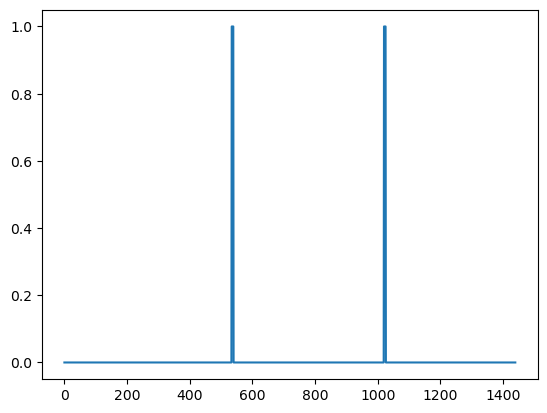

In [3]:
plt.plot(create_profile(9*60,17*60,20))
plt.show()

Hoppla!? Haben wir da was falsch programmiert? Nein, das passt so. 20 Minuten von einem 24 Stunden Tag sind tatsächlich nur ein paar Pixel. Das sieht jetzt zwar extrem ineffizient aus, aber man darf nicht vergessen, dass Autos trotzdem 10 mal so effizient genutzt werden wie Zahnbürsten, die ja nur 4 Minuten am Tag ihre Leistung erbringen.

Um das genauer zu analysieren brauchen wir natürlich mehr als eine Person. Wir wollen jetzt eine ganze Liste von solchen Mobilitätsprofilen. Und die sollen nicht alle exakt gleich sein. Aber: Sehr viele sollen gleich sein: 9 bis 5 ist nunmal Standard. Und die Situation gibt es in oft: Wir schreiben eine Function und für jedes Argument gibt es einen Standardwert. Das können wir auch genau so in die Function selbst einbauen:

In [4]:
def create_profile(work_start = 9*60, work_end=17*60, commute=20):
    """
    One daily car-use profile (1440 minutes, 1=using car, 0=not using).
    """
    day_min = 24 * 60
    prof = [0] * day_min

    commute = commute + int(random.uniform(-20,40))

    # commute to work
    commute_to_start = work_start - commute
    commute_to_end = work_start
    for m in range(commute_to_start, commute_to_end):
        prof[m] = 1

    # commute back home
    commute_back_start = work_end
    commute_back_end =  work_end + commute
    for m in range(commute_back_start, commute_back_end):
        prof[m] = 1


    return prof

Wenn wir die Function so definieren, weiß Python, dass es einen Standardwert gibt. Der wird verwendet, wenn wir nichts anderes sagen. Solche Functions haben viele Vorteile:

* Wir können sie sehr schnell mit `create_profile()` aufrufen
* Wenn wir ein Argmuent anders haben wollen, reicht es z.B. mit ``create_profile(commute=10)`` aufzurufen
* Wir müssen uns nicht merken, welches Argument an welcher Position steht

Vor allem für Functions mit vielen Arugmenten überwiegen die Vorteile schnell. Man kann aber auch *positional arguments* mit *keyword arguments* mischen. solange positional vorne stehen. Das haben wir sogar schon oft gemacht. `plt.plot(xwerte,ywerte, c='forestgreen'` ist ein Beispiel dafür: `xwerte` und `ywerte` sind positional arguments und `c` ist ein keyword argument. Der klare Voteil hier: wir müssen nur das deklarieren, was wir anders haben wollen. Wenn wir keine Farbe angeben wird der Plot einfach blau, geht auch. Wenn wir blau jedes Mal dazuschreiben müssten, um überhaupt einen Plot zu bekommen, wäre `plt.plot` effektiv nicht nutzbar. Denn es gibt etwa 40 keyword Argumente.

Nutzen wir dieses Wissen über Keyword Arguments um 200 Mobilitätsprofile zu erstellen: 100 "normale", 50 "Halbtag" (also von 8 bis 12) und 50 flexible.

In [5]:
def create_pop_base():
    """
    100 default (9-17), 50 morning (8-12), 50 random.
    """
    pop = []

    # 100 default: 9-17
    for it in range(100):
        prof = create_profile()
        pop.append(prof)

    # 50 morning: 8-12
    for it in range(50):
        prof = create_profile(work_start=8 * 60,work_end=12 * 60)
        pop.append(prof)

    # 50 random patterns
    for it in range(50):
        prof = create_profile(
            work_start=int(random.uniform(7*60,11*60)),
            work_end=int(random.uniform(12*60,20*60)),
            commute=int(random.uniform(5,30)),
        )
        pop.append(prof)

    return pop

Nun analysieren wir diese Population. Zuerst rechnen wir aus, wie viel Stehzeit die Autos im Mittel haben. Dafür Summieren wir einfach die Minuten, in denen ein Auto genutzt wird auf und dividieren durch die Gesamtzahl der Minuten mal der 200 Personen.

In [6]:
def efficiency(pop):
    """
    Average usage/idle minutes
    """
   
    total_use = 0

    for prof in pop:
        use = sum(prof)
        total_use += use
       
    return total_use / (60 * 24 * 200)

Wir erstellen eine Population und berechnen die Auslastung:

In [12]:
base_pop = create_pop_base()
eff = efficiency(base_pop)
print(eff)

0.03933333333333333


Ja nach Zufallszahlen, die gewürfelt werden kommt immer was etwas anderes raus, aber Größenordnung 4% fahren und 96% stehen. Das klingt nach sehr viel Stehzeit. Aber man muss dazusagen: wir haben hier nur den Arbeitsweg. Menschen fahren ja auch noch Einkaufen oder zum Spaß und nicht jeder Mensch hat ein eigenes Auto. Wer sich dafür interessiert kann in der Literatur nachschauen, wie viel Stehzeit ein Auto tatsächlich hat. (Spoiler: Laut VCÖ sind es 95.8% bis 96%)

Sehen wir uns das als Grafik an: Dafür müssen wir für jede Minute des Tages einfach alle Autos, die gerade unterwegs sind aufsummieren. Das machen wir auch in einer Function:

Text(0.5, 0, 'time (min after midnight)')

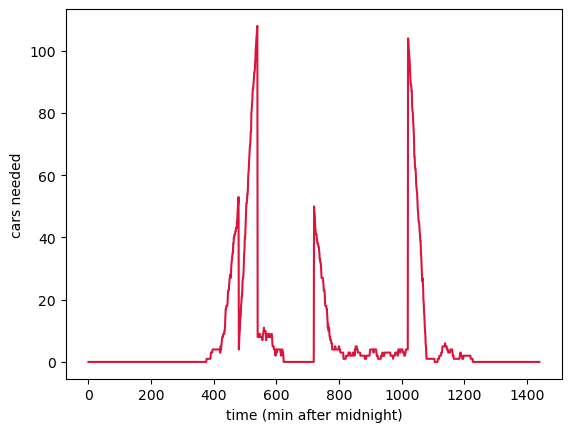

In [18]:
def car_use(pop):
    """
    How many cars are needed each minute
    """
    day_min = 24 * 60
    cars_per_min = [0] * day_min

    for minute in range(day_min):
        for person in pop:
            cars_per_min[minute] += person[minute]


    return cars_per_min

usage = car_use(base_pop)
plt.figure()
plt.plot(usage,c="crimson")
plt.ylabel("cars needed")
plt.xlabel("time (min after midnight)")

Wenn man plots erstellt ist es meist auch eine gute Idee, diesen Prozess in eine Function auszulagern. Machen wir das hier, aber verwenden wir die Farbe als keyword argument, sonst könnten wir sie dann von außen nicht mehr ändern.

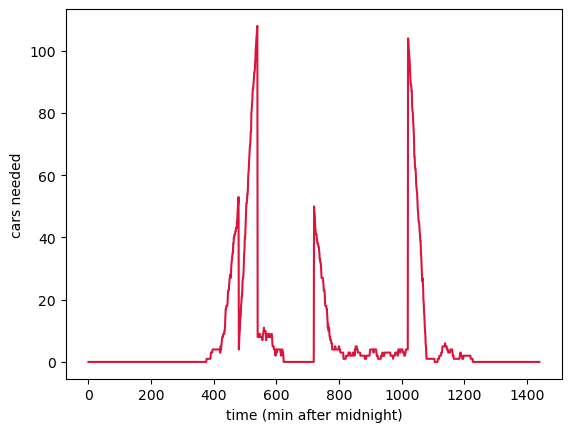

In [19]:
def make_plot(data,c="crimson"):
    plt.figure()
    plt.plot(data,c=c)
    plt.ylabel("cars needed")
    plt.xlabel("time (min after midnight)")

make_plot(usage)

Interessant wre jetzt auch, wie viele Autos wir für 200 Personen wirklich benötigen würden, wenn wir perfekt sharen könnten (durch autonome Fahrzeuge oder sonst eine Technologie). Das ist einfach das Maximum der Autos, die gleichzeitig auf der Straße sind. Im Plot kann man es erahnen, aber bauen wir es als return Wert in unsere `car_use` function ein.

Problem: `car_use` hat schon einen return wert.    
Lösung: `car_use` bekommt einen zweiten return wert. 

Das geht, man kann ihn einfach mit einem Beistrich trennen, gleich wie bei positional arguments. Aber Achtung: wenn man den Output von einer Function, die zwei return werte hat speichern will, muss man auch zwei Speicherplätze zur Verfügung stellen. Das sieht so aus:

In [21]:
def car_use(pop):
    """
    How many cars are needed each minute
    """
    day_min = 24 * 60
    cars_per_min = [0] * day_min

    for minute in range(day_min):
        for person in pop:
            cars_per_min[minute] += person[minute]

    maxi = max(cars_per_min)

    return cars_per_min, maxi

usage,maxi=car_use(base_pop)
print(maxi)

108


Wenn wir also perfekt sharen könnten wir etwa die Hälfte der Autos einsparen. Das Problem sind scheinbar unsere Arbeitszeiten. Wenn alle um 9 im Büro sein müssen, brauchen eben alle ein eigenes Auto. Machen wir mal eine andere Population, mit ganz flexiblen Arbeitszeiten. Vielleicht verbessert das etwas.

In [22]:
def create_pop_flex():
   
    pop = []

    # 200 flexible: 
    for it in range(200):
        prof = create_profile(
            work_start=int(random.uniform(7*60,11*60)),
            work_end=int(random.uniform(12*60,20*60))
        )
        pop.append(prof)

    return pop

Wenn wir wollen können wir die beiden verwandten create_pop Functions auch zusammenfassen:

In [23]:
def make_pop(version="base"):
    if version == "base":
        pop= create_pop_base()
    elif version == "flex":
        pop= create_pop_flex()
    else:
        print("no such pop",version)
        pop=[[]]
    return pop

Wenn man nichts weiter angibt, bekommt man die Basis-Population und wenn man als version "flex" mitgibt, entsteht die Population mit flexiblen Arbeitszeiten. Sollte man eine version verlangen, die es nicht gibt, bekommt man nur eine leere Population und die Meldung, das etwas nicht geklappt hat als print.

Jetzt können wir die Populationen vergleichen.

0.041243055555555554
104
34


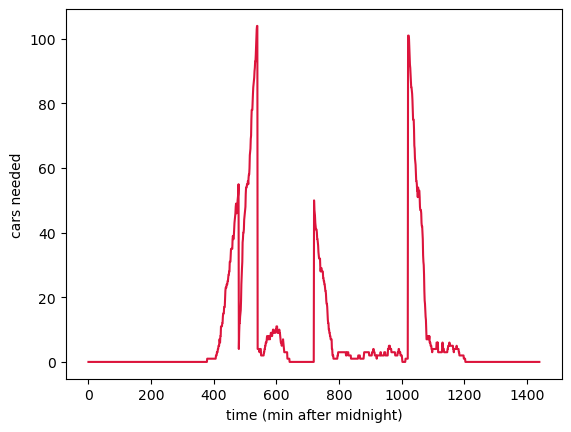

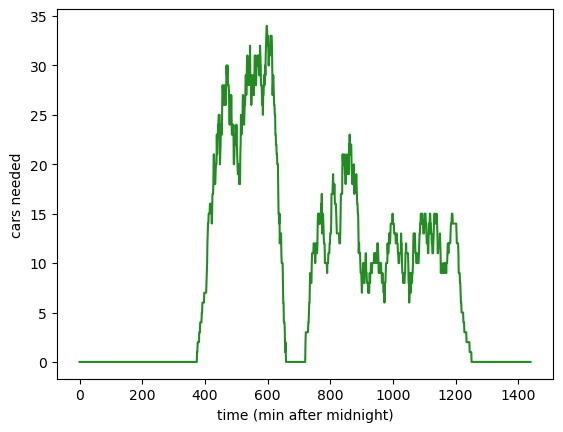

In [25]:
def make_pop(version="base"):
    if version == "base":
        pop= create_pop_base()
    elif version == "flex":
        pop= create_pop_flex()
    else:
        print("no such pop",version)
        pop=[[]]
    return pop




# base population
base_pop = make_pop()
eff = efficiency(base_pop)
print(eff)

usage,maxi=car_use(base_pop)
make_plot(usage)
print(maxi)


flex_pop = make_pop(version="flex")

usage,maxi=car_use(flex_pop)
make_plot(usage,c="forestgreen")
print(maxi)

plt.show()

Das sieht vielversprechend aus. Wir konnten auf etwa 30 Autos reduzieren. Jedes mal wen wir das Programm laufen lassen, kommt aber was anderes raus (weil die Zufallszahlen zufällig sind). Auch dafür gibt es eine Lösung: Wir können in Python einen so genannten *random seed* wählen. Dadurch bleiben unsere Zahlen "zufällig", aber es sind sozusagen immer die gleichen Zufallszahlen. Am besten versteht man das mit einem Beispiel:

Wir erstellen 3 Zufallszahlen zwischen 0 und 100. Beim ersten mal bekommen wir 67, 21, 97. Wenn wir das Programm nochmal laufen lassen, bekommen wir 19,72,61.  
Wenn wir jetzt aber einen Seed setzen bekommen wir beim ersten mal 18,31,88 und beim nächsten mal auch wieder 18,31,88. Das macht die Zahlen innerhalb eines runs nicht weniger zufällig, aber es sind eben immer die gleichen. LLMs haben z.B. auch einen Seed. Wenn wir dort einen See setzen würden würden wir für den gleichen Prompt auch exakt den gleichen Output bekommen (vllt mit minmalen Abweichungen durch watermarking der andere geheime Dinge).

Einen Seed setzt man so

In [26]:
random.seed(100)

Aber egal welchen Seed wir setzen: Die Grafik sieht immer ein wenig anders aus, aber wir werden immer so um die 30 Fahrzeuge brauchen. Wäre das perfekte Sharen möglich würden wir, zumindest in unserem stark vereinfachten System von 200 auf 30 Autos reduzieren können. Das wäre eine große Einsparung. Natürlich würde das in echt an vielen Dingen scheitern. Aber was wir aus dem Modell lernen: auch wenn alles perfekt wäre: weniger als 30 Autos auf 200 Personen schaffen wir in keinem Fall. Somit haben wir eine obere Schranke für die maximale Auslastung von PKWs in unserer Gesellschaft: etwa 25%. Oder umgerechnet: Über 60 Zahnbürsteneffizienzen.

# Zusammenfassung

**Positional vs. Keyword Arguments**  
In Python können Funktionen mit positional und mit keyword arguments aufgerufen werden. Bei positional arguments werden die Werte in der Reihenfolge der Parameter in der Funktionsdefinition übergeben, z.B. `func(10, 20)`. Bei keyword arguments werden die Parameter explizit beim Namen angegeben, z.B. `func(x=10, y=20)`. Das erlaubt, Argumente in beliebiger Reihenfolge zu übergeben und macht den Code meist besser lesbar. In einem Funktionsaufruf müssen positional arguments immer vor keyword arguments stehen, also `func(10, y=20)` ist gültig, `func(x=10, 20)` dagegen nicht. Das Zusammenspiel der beiden Arten ist wichtig, um flexible und gut verständliche Schnittstellen zu definieren.

**Default Values von Keyword Arguments** 
In der Funktionsdefinition kann man für Parameter Standardwerte (default values) festlegen, z.B. `def func(a, b=5, c="x")`:. Wenn die Funktion aufgerufen wird, können diese Parameter weggelassen werden; dann wird der Standardwert verwendet. Ruft man `func(10)` auf, gilt b=5 und c="x". Durch keyword arguments kann man einzelne Default-Parameter gezielt überschreiben, z.B. `func(10, c="y")`. Wichtig ist die Reihenfolge in der Definition: Parameter mit Default-Wert müssen nach den Parametern ohne Default-Wert kommen, also `def func(a, b=5)` ist erlaubt, `def func(a=5, b)` nicht.

**Mehrere Return-Werte**   
Eine Python-Funktion kann mehr als einen Wert „zurückgeben“, indem man die mit Beistreichen trennt, z.B. return x, y, z. So ein Objekt heißt Tupel (auch wenn es mehr als zwei Einträge hat). Technisch ist es immer genau ein Objekt (das Tupel), aber Python erlaubt bequemes „multiple assignment“ beim Aufruf: a, b, c = func(). So lassen sich mehrere voneinander abhängige Ergebnisse gleichzeitig zurückgeben, ohne eigene Hilfsstrukturen definieren zu müssen. Wer nicht alle Rückgabewerte braucht, kann einzelne mit _  ignorieren, z.B. `a, _ = func()` . Dieses Muster verbessert die Klarheit von Funktionen, die mehrere zusammengehörige Ergebnisse berechnen.


**Random Seed**    
Der random-Modul in Python generiert pseudozufällige Zahlen: Die Werte sind „zufällig genug“ für viele Zwecke, aber deterministisch, wenn man denselben Startzustand (Seed) verwendet. Mit `random.seed(some_number)` setzt man diesen Startzustand. Danach erzeugt jede Folge von Aufrufen (random.random(), random.randint(...) usw.) immer dieselbe Zahlenfolge, solange der Seed gleich und die Aufrufreihenfolge identisch ist. Das ist besonders wichtig für Reproduzierbarkeit: Tests, Simulationen oder Experimente, die Zufall verwenden, liefern mit demselben Seed immer identische Ergebnisse, was Debugging und Vergleich von Läufen stark vereinfacht. Ohne gesetzten Seed verwendet Python einen systemabhängigen Startwert (z.B. aktuelle Zeit), sodass die Folge von Zufallszahlen bei jedem Programmstart anders ist.